# Random Forest


<b> Objective: </b>
Conduct Experiments with Random Forest

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>

### Imports

In [81]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [84]:
import sys
COLAB_SESSION = False

if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)      # so GreenlandUtils.py is importable
else:
    DRIVE_PATH = ""

import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import  RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_absolute_error
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from GreenlandUtils import lonlatToUTM24N, Split, verifyStratification, displaySplit, MostCommonElements, Printable

### Setup

In [67]:
DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"
metaCols = ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr']


def ReadDataFrame(path: str, baseName: str) -> pd.DataFrame:
    return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")

def ReadSplit(path: str, baseName: str, df: pd.DataFrame) -> Split:
    with open(f"{DRIVE_PATH}{path}{baseName}.split", "r") as f:
        json_result = json.load(f)

    return Split({name: df.loc[idx] for name, idx in json_result.items()})

def ReadKFold(path: str, baseName: str, df: pd.DataFrame) -> list[Split]:
    with open(f"{DRIVE_PATH}{path}{baseName}.kfold", "r") as f:
        json_result = json.load(f)

    #Fold indices are stored as strings, so sort them numerically
    return [Split({name: df.loc[idx] for name, idx in json_result[key].items()})
            for key in sorted(json_result, key=int)]


df = ReadDataFrame(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Data")
split = ReadSplit(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Holdout", df)
kfold_splits = ReadKFold(f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "5-Fold", df)

elementCols = [col for col in df.columns if col not in metaCols]

#A column measured in almost no samples carries nothing, and breaks the binning
#HistGradientBoosting does when a whole fold sees fewer than two distinct values
MIN_COVERAGE = 10
coverage = df[elementCols].notna().sum()
droppedCols = [col for col in elementCols if coverage[col] < MIN_COVERAGE]
elementCols = [col for col in elementCols if coverage[col] >= MIN_COVERAGE]

mostCommonElements = MostCommonElements(df, elementCols, top_n=10)
mostCommonElements = [element for element, _ in mostCommonElements]

print(f"Samples: {len(df)}   Elements: {len(elementCols)}   Folds: {len(kfold_splits)}")
print(f"Dropped ({len(droppedCols)}, under {MIN_COVERAGE} samples): {droppedCols}")
print(f"Targets: {mostCommonElements}")

Analyzing Elements: 100%|██████████| 68/68 [00:00<00:00, 5804.67it/s]

Samples: 6957   Elements: 68   Folds: 5
Dropped (8, under 10 samples): ['B ppm', 'Ru ppb', 'Rh ppb', 'Te ppm', 'I ppm', 'Re ppb', 'Os ppb', 'Ir ppb']
Targets: ['CaO wt%', 'MnO wt%', 'TiO2 wt%', 'K2O wt%', 'Na2O wt%', 'Zn ppm', 'Sr ppm', 'Al2O3 wt%', 'MgO wt%', 'Ni ppm']


In [68]:
def ValidateKFold(kfold_splits: list[Split], df: pd.DataFrame):
    test_sets = [set(s.data["test"].index) for s in kfold_splits]

    print("test sizes:", [len(t) for t in test_sets])
    print("union:", len(set().union(*test_sets)), "of", len(df))
    print("pairwise overlaps:", [len(a & b) for i, a in enumerate(test_sets)
                                            for b in test_sets[i+1:]])

    for i, s in enumerate(kfold_splits):
        tr, te = set(s.data["train"].index), set(s.data["test"].index)
        print(f"fold {i}: train {len(tr)}, test {len(te)}, leak {len(tr & te)}")


ValidateKFold(kfold_splits, df)

test sizes: [1392, 1392, 1391, 1391, 1391]
union: 6957 of 6957
pairwise overlaps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
fold 0: train 5565, test 1392, leak 0
fold 1: train 5565, test 1392, leak 0
fold 2: train 5566, test 1391, leak 0
fold 3: train 5566, test 1391, leak 0
fold 4: train 5566, test 1391, leak 0


### Naive Random Forest

In [85]:
def ArrangeData(df: pd.DataFrame, element: str, elementCols: list[str]):
    df = df.copy()
    df = df.dropna(subset=[element])
    X = df[elementCols].copy()
    y = df[element].copy()
    X = X.drop(columns=[element], errors='ignore')

    return X, y

def DropDegenerateColumns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    #A KNN column can end up constant or near-empty on a given fold even when its
    #source element is fine, which is the one input HistGradientBoosting cannot bin
    usable = [col for col in X_train.columns if X_train[col].nunique(dropna=True) >= 2]

    return X_train[usable], X_test[usable]

def MakeModel(modelType: str="hgb", n_jobs: int=-1, estimators: int=200):
    #HistGradientBoosting threads internally and takes no n_jobs
    if modelType == "rf":
        return RandomForestRegressor(n_estimators=estimators, random_state=42, n_jobs=n_jobs)
    return HistGradientBoostingRegressor(max_iter=estimators, random_state=42)

def TrainRandomForest(df_train: pd.DataFrame, df_test: pd.DataFrame, element: str, elementCols: list[str], n_jobs:int=-1, estimators:int=200, modelType:str="hgb"):
    X_train, y_train = ArrangeData(df_train, element, elementCols)
    X_test, y_test = ArrangeData(df_test, element, elementCols)

    if X_train.empty or X_test.empty:
        return { "r2": None, "mae": None }

    X_train, X_test = DropDegenerateColumns(X_train, X_test)
    if X_train.empty:
        return { "r2": None, "mae": None }

    model = MakeModel(modelType, n_jobs=n_jobs, estimators=estimators)
    model.fit(X_train, y_train)

    r2 = model.score(X_test, y_test)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return { "r2": r2, "mae": mae, "y_pred": y_pred, "y_test": y_test }



train, test = split.data["train"], split.data["test"]

for modelType in ("rf", "hgb"):
    score = TrainRandomForest(train, test, element="CaO wt%", elementCols=elementCols, estimators=40, modelType=modelType)
    print(f"{modelType:>4}   R2: {score['r2']:.4f}   MAE: {score['mae']:.4f}")

  rf   R2: 0.7897   MAE: 0.1679
 hgb   R2: 0.8004   MAE: 0.1696


In [70]:
from joblib import Parallel, delayed


def TrainAllElements(split: Split, elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, modelType: str="hgb", **kwargs):

    train, test = split.data["train"], split.data["test"]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(train, test, element, elementCols, n_jobs=1, modelType=modelType)
        for element in elementsToTrain
    )

    return dict(zip(elementsToTrain, scores))

def TrainAllElementsKFold(kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, modelType: str="hgb", **kwargs):

    jobs = [
        (element, foldIdx, split)
        for element in elementsToTrain
        for foldIdx, split in enumerate(kfold_splits)
    ]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(
            split.data["train"], split.data["test"], element, elementCols, n_jobs=1, modelType=modelType
        )
        for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results

MODEL_TYPE = "hgb"

results = TrainAllElements(split, mostCommonElements, elementCols, n_jobs=-1, modelType=MODEL_TYPE)
results_kfold = TrainAllElementsKFold(kfold_splits, mostCommonElements, elementCols, n_jobs=-1, modelType=MODEL_TYPE)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   16.9s remaining:   39.5s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   17.1s remaining:   17.1s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   17.2s remaining:    7.3s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   18.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:   21.4s remaining:    4.6s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:   22.6s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   24.4s 

In [71]:
def SaveResults(results: dict, path: str, baseName: str):
    for _, score in results.items():
        if "y_pred" in score:
            score["y_pred"] = score["y_pred"].tolist() if not isinstance(score["y_pred"], list) else score["y_pred"]
        if "y_test" in score:
            score["y_test"] = score["y_test"].tolist() if not isinstance(score["y_test"], list) else score["y_test"]

    with open(f"{DRIVE_PATH}{path}{baseName}.json", "w") as f:
        json.dump(results, f, indent=4)

def AggregateFolds(kfoldResults: dict):
    aggregated = {}

    for element, folds in kfoldResults.items():
        valid = [s for s in folds.values() if s["r2"] is not None and not np.isnan(s["r2"])]
        if not valid:
            aggregated[element] = { "r2": None, "mae": None }
            continue

        aggregated[element] = {
            "r2": float(np.mean([s["r2"] for s in valid])),
            "r2_std": float(np.std([s["r2"] for s in valid])),
            "mae": float(np.mean([s["mae"] for s in valid])),
            "y_pred": np.concatenate([s["y_pred"] for s in valid]),
            "y_test": np.concatenate([s["y_test"] for s in valid]),
        }

    return aggregated

#Model name goes in the filename so RF and HGB runs do not overwrite each other
MODEL_NAMES = { "rf": "RandomForest", "hgb": "HistGradientBoosting", "xgb": "XGBoost" }

SaveResults(results, f"Results/", f"{MODEL_NAMES[MODEL_TYPE]}")
SaveResults(AggregateFolds(results_kfold), f"Results/", f"{MODEL_NAMES[MODEL_TYPE]}_KFold")

In [72]:
def PooledR2Log(results: dict):
    ss_res, ss_tot = 0.0, 0.0

    for score in results.values():
        if score["r2"] is None or "y_test" not in score:
            continue

        y_test = np.asarray(score["y_test"], dtype=float)
        y_pred = np.asarray(score["y_pred"], dtype=float)

        #Log10 scale so wt%/ppm/ppb elements contribute comparably (drop BDL zeros)
        valid = (y_test > 0) & (y_pred > 0)
        if valid.sum() < 2:
            continue

        y_test_log = y_test[valid]
        y_pred_log = y_pred[valid]

        ss_res += ((y_test_log - y_pred_log) ** 2).sum()
        ss_tot += ((y_test_log - y_test_log.mean()) ** 2).sum()

    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def GlobalScores(printable: Printable, results: dict):
    valid_r2 = [s["r2"] for s in results.values() if s["r2"] is not None and not np.isnan(s["r2"])]

    printable.add("Mean R2 Score", f"{np.mean(valid_r2):.4f}")
    printable.add("Median R2 Score", f"{np.median(valid_r2):.4f}")
    printable.add("Pooled R2 Score (log10)", f"{PooledR2Log(results):.4f}")

def ReportResults(results: dict, title: str = "Element Scores"):
    printable = Printable()
    printable.title(title)
    for element, score in results.items():
        if score["r2"] is None:
            continue

        r2 = f"R2: {score['r2']:>8.4f}"
        #r2_std only exists for k-fold results, so pad single-split rows to match
        if "r2_std" in score:
            r2 += f" ± {score['r2_std']:.4f}"
        else:
            r2 += " " * 9

        printable.add(element, f"{r2}   MAE: {score['mae']:.4f}")

    printable.rest()
    printable.title("Global Score")

    GlobalScores(printable, results)

    printable.pretty()

ReportResults(results, "Holdout")

ReportResults(AggregateFolds(results_kfold), "5-Fold")

========================== Holdout ==========================
CaO wt%:                   R2:   0.8428            MAE: 0.1529
MnO wt%:                   R2:   0.8402            MAE: 0.1305
TiO2 wt%:                  R2:   0.8610            MAE: 0.1241
K2O wt%:                   R2:   0.8396            MAE: 0.1783
Na2O wt%:                  R2:   0.8385            MAE: 0.1642
Zn ppm:                    R2:   0.7160            MAE: 0.1677
Sr ppm:                    R2:   0.8343            MAE: 0.1833
Al2O3 wt%:                 R2:   0.8997            MAE: 0.0742
MgO wt%:                   R2:   0.9132            MAE: 0.1253
Ni ppm:                    R2:   0.8582            MAE: 0.1930


======================== Global Score ========================
Mean R2 Score:             0.8443
Median R2 Score:           0.8415
Pooled R2 Score (log10):   0.7987
=========================== 5-Fold ===========================
CaO wt%:                   R2:   0.8383 ± 0.0101   MAE: 0.1481
MnO wt%:       

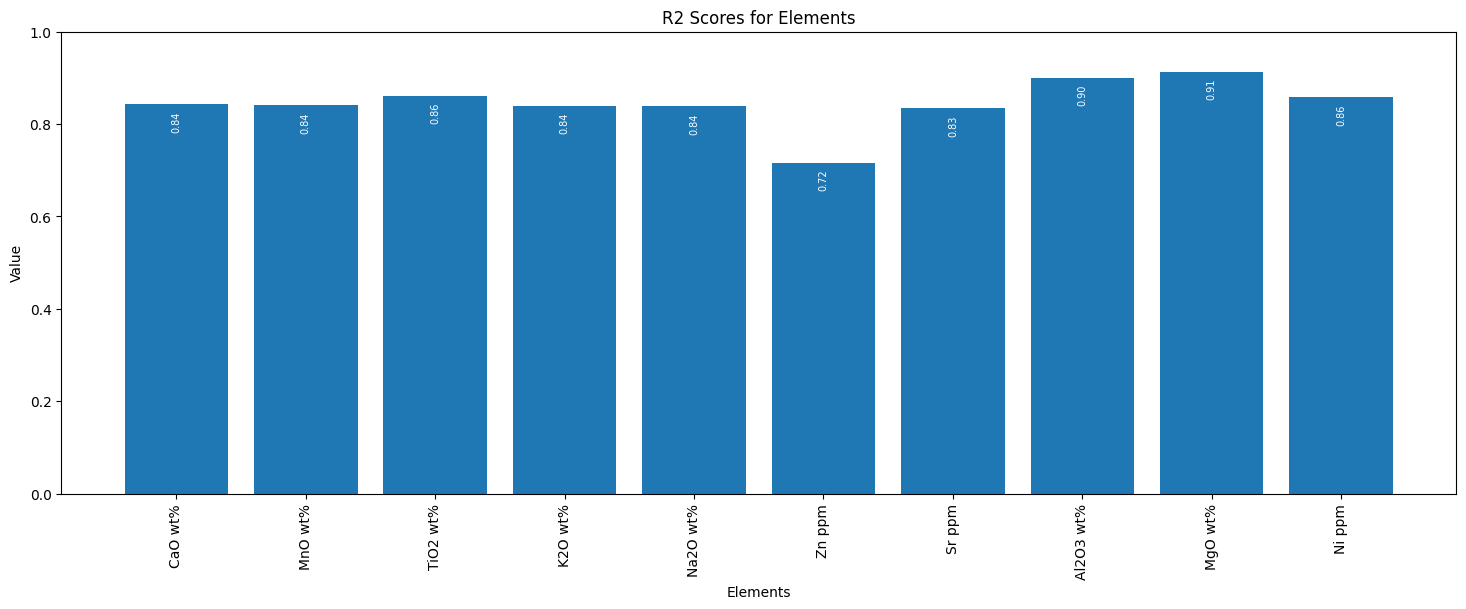

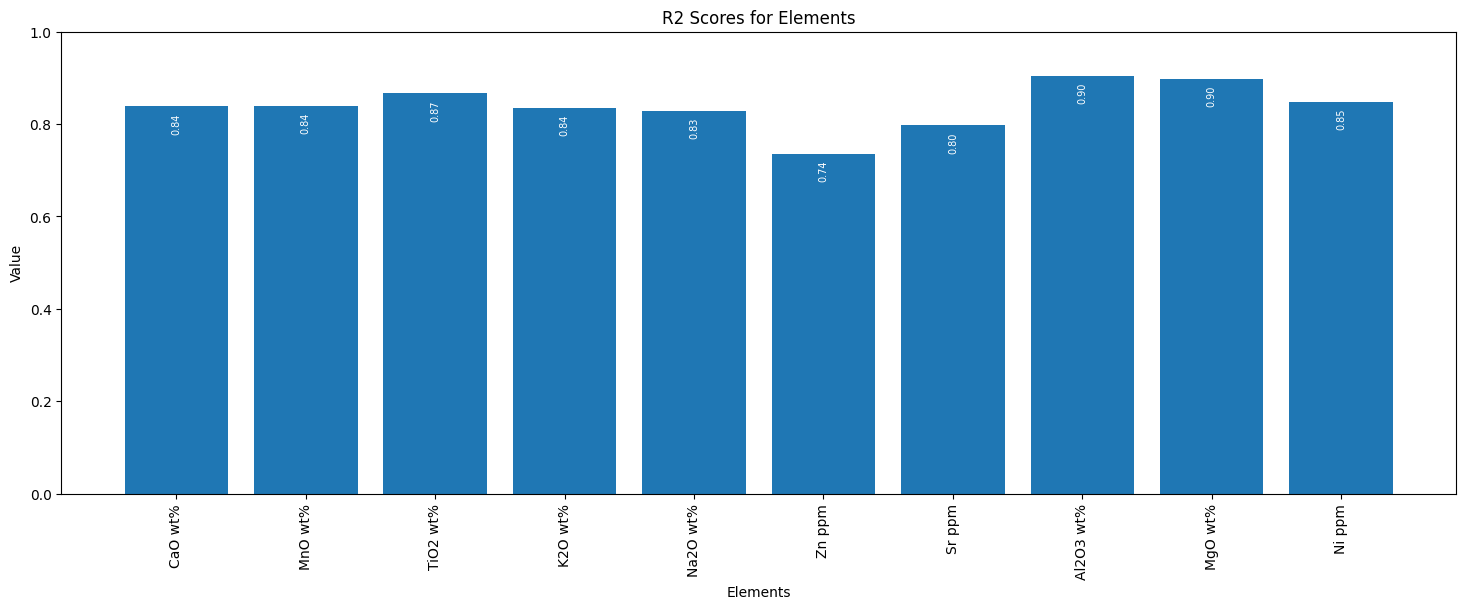

In [73]:
def DisplayElementScores(elementScores: dict):
    scores_df = pd.DataFrame.from_dict(elementScores, orient='index')
    scores_df = scores_df[['r2', 'mae']]
    display(scores_df)

def DisplayElementScoresGraph(elementScores:dict, metric="r2", title="Element Scores"):

    scores = []
    for element, score in elementScores.items():
        if score[metric] is not None:
            scores.append((element, score[metric]))

    labels, values = zip(*scores)


    plt.figure(figsize=(18, 6))
    bars = plt.bar(labels, values)
    plt.bar_label(bars, fmt="%.2f", padding=-20, rotation=90, fontsize=7, color="white")
    plt.ylim(0, 1)
    plt.xlabel("Elements")
    plt.ylabel("Value")
    plt.xticks(rotation=90)
    plt.title(title)

    plt.show()

DisplayElementScoresGraph(results, metric="r2", title="R2 Scores for Elements")
DisplayElementScoresGraph(AggregateFolds(results_kfold), metric="r2", title="R2 Scores for Elements")

### Random Forest + K Nearest Neighbours

##### Building the Neighbour Mapping

In [74]:
def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def BuildNeighbourMapping(df: pd.DataFrame, split: Split, k: int = 20, excludeSameLocation: bool = False) -> tuple[np.ndarray, np.ndarray]:

    #Build context around only train split
    allCoords = ProjectedCoords(df)
    trainPos = df.index.get_indexer(split.data["train"].index)
    trainCoords = allCoords[trainPos]

    #Fetch a good amount of neighbours if we are excluding co-located samples since we need filter out later (aka max equal coords padding)
    #If including co-located samples, just filter out self (aka 1 padding)
    padding = int(df.groupby(["Longitude", "Latitude"]).size().max()) if excludeSameLocation else 1
    nNeighbours = min(k + padding, len(trainPos))

    tree = NearestNeighbors(n_neighbors=nNeighbours).fit(trainCoords)
    distances, positions = tree.kneighbors(allCoords)
    neighbourPos = trainPos[positions]

    #Exlude self and distance 0 neighbours
    rejected = neighbourPos == np.arange(len(df))[:, None]
    if excludeSameLocation:
        rejected |= distances == 0

    distances = np.where(rejected, np.inf, distances)
    ordered = np.argsort(distances, axis=1)[:, :k]

    return np.take_along_axis(neighbourPos, ordered, axis=1), np.take_along_axis(distances, ordered, axis=1)


def BuildNeighbourValues(df: pd.DataFrame, elementCols: list[str], neighbourPos: np.ndarray, neighbourDist: np.ndarray, k: int = 5) -> np.ndarray:

    elements = df[elementCols].to_numpy(dtype=float)

    values = elements[neighbourPos[:, :k]]
    values[~np.isfinite(neighbourDist[:, :k])] = np.nan

    return values


def NeighbourMeans(neighbourValues: np.ndarray) -> np.ndarray:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmean(neighbourValues, axis=1)


neighbourPos, neighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=5)
neighbourValues = BuildNeighbourValues(df, elementCols, neighbourPos, neighbourDist, k=5)

printable = Printable()
printable.title("Neighbour Mapping Info")
printable.add("Mapping Shape", neighbourPos.shape)
printable.add("Values Shape", neighbourValues.shape) #samples x neighbours x elements
printable.rest()
printable.add("Distances Median", f"{np.median(neighbourDist)/1000:.3f}")
printable.add("Distances Mean", f"{np.mean(neighbourDist)/1000:.3f}")
printable.add("Distances at 0m", f"{len(neighbourDist == 0)}")
printable.flush()

========= Neighbour Mapping Info =========
Mapping Shape:      (6957, 5)
Values Shape:       (6957, 5, 68)


Distances Median:   0.343
Distances Mean:     1.626
Distances at 0m:    6957


##### KNN Variants

In [75]:
#Mean target element
def CreateKNNFrame_A(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    target = elementCols.index(element)
    means = NeighbourMeans(neighbourValues)[:, target]
    return pd.DataFrame({f"{k}-KNN_{element}_mean": means}, index=df.index)

#Individual target element values
def CreateKNNFrame_B(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    target = elementCols.index(element)
    columns = {f"{i+1}of{k}-KNN_{element}": neighbourValues[:, i, target] for i in range(k)}
    return pd.DataFrame(columns, index=df.index)

#All element means
def CreateKNNFrame_C(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    means = NeighbourMeans(neighbourValues)
    columns = {f"{k}-KNN_{e}_mean": means[:, j] for j, e in enumerate(elementCols)}
    return pd.DataFrame(columns, index=df.index)

#All element individual values
def CreateKNNFrame_D(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    columns = {f"{i+1}of{k}-KNN_{e}": neighbourValues[:, i, j]
               for j, e in enumerate(elementCols) for i in range(k)}
    return pd.DataFrame(columns, index=df.index)


KNN_VARIANTS = { "A": CreateKNNFrame_A, "B": CreateKNNFrame_B, "C": CreateKNNFrame_C, "D": CreateKNNFrame_D }

for name, builder in KNN_VARIANTS.items():
    frame = builder(df, elementCols, "CaO wt%", neighbourValues, 5)
    printable.add(f"Variant {name}", f"{frame.shape[1]:>3} added columns")

printable.flush()

Variant A:     1 added columns
Variant B:     5 added columns
Variant C:    68 added columns
Variant D:   340 added columns


##### Training

In [ ]:
def TrainAllElementsKFoldKNN(df: pd.DataFrame, kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, k: int=5, maskFunction: callable =CreateKNNFrame_A, excludeSameLocation: bool=False, modelType: str="hgb", **kwargs):

    jobs = [] # element x (foldIdx, split)
    dfs = {} # (element, foldIdx) -> DataFrame

    #Build neighbour mapping per fold 
    for foldIdx, split in enumerate(kfold_splits):
        neighbourPos, neighbourDist = BuildNeighbourMapping(df, split, k=k, excludeSameLocation=excludeSameLocation)
        neighbourValues = BuildNeighbourValues(df, elementCols, neighbourPos, neighbourDist, k=k)

        for element in elementsToTrain:
            dfs[(element, foldIdx)] = maskFunction(df, elementCols, element, neighbourValues, k)
            jobs.append((element, foldIdx, split))
    

    def TrainJob(element, foldIdx, split):
        frame = dfs[(element, foldIdx)]
        full = pd.concat([df[elementCols], frame], axis=1)
        return TrainRandomForest(
            full.loc[split.data["train"].index],
            full.loc[split.data["test"].index],
            element,
            elementCols + frame.columns.tolist(),
            n_jobs=1,
            estimators=200,
            modelType=modelType
        )

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainJob)(element, foldIdx, split) for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results


results_kfold_knn = {}
MODEL_TYPE = "xgboost"

for name, maskFunction in KNN_VARIANTS.items():
    results_kfold_knn[name] = TrainAllElementsKFoldKNN(df, kfold_splits, mostCommonElements, elementCols, n_jobs=-1, k=5, maskFunction=maskFunction, excludeSameLocation=True, modelType=MODEL_TYPE)
    SaveResults(AggregateFolds(results_kfold_knn[name]), f"Results/", f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_{name}_ExcludingColocation")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:   31.4s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:   36.4s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   38.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   22.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   2

In [78]:
for name in KNN_VARIANTS:
    ReportResults(AggregateFolds(results_kfold_knn[name]), f"5-Fold + KNN {name}")

======================= 5-Fold + KNN A =======================
CaO wt%:                   R2:   0.8379 ± 0.0109   MAE: 0.1486
MnO wt%:                   R2:   0.8435 ± 0.0098   MAE: 0.1219
TiO2 wt%:                  R2:   0.8682 ± 0.0074   MAE: 0.1136
K2O wt%:                   R2:   0.8400 ± 0.0079   MAE: 0.1802
Na2O wt%:                  R2:   0.8305 ± 0.0083   MAE: 0.1609
Zn ppm:                    R2:   0.7433 ± 0.0133   MAE: 0.1636
Sr ppm:                    R2:   0.8048 ± 0.0164   MAE: 0.1907
Al2O3 wt%:                 R2:   0.9054 ± 0.0122   MAE: 0.0731
MgO wt%:                   R2:   0.8976 ± 0.0181   MAE: 0.1277
Ni ppm:                    R2:   0.8495 ± 0.0149   MAE: 0.1944


======================== Global Score ========================
Mean R2 Score:             0.8421
Median R2 Score:           0.8418
Pooled R2 Score (log10):   0.8028
======================= 5-Fold + KNN B =======================
CaO wt%:                   R2:   0.8399 ± 0.0044   MAE: 0.1471
MnO wt%:      

### Results Comparison

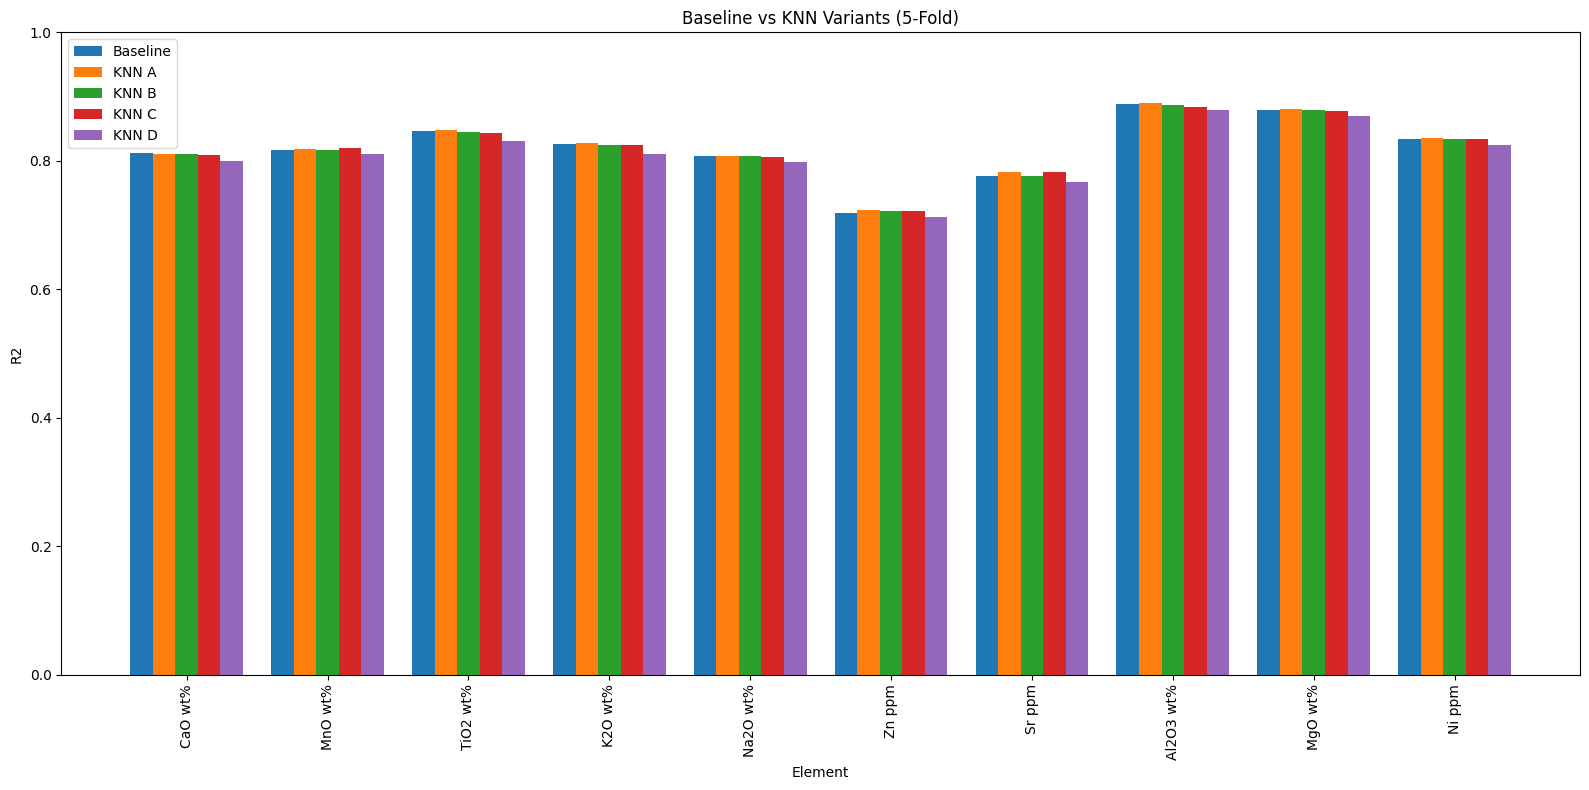

In [63]:
def CompareVariantsOnGraph(allResults: dict[str, dict], elements: list[str], metric="r2", title="Comparison of KNN Variants"):
    names = list(allResults.keys())
    x = np.arange(len(elements))
    width = 0.8 / len(names)

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, name in enumerate(names):
        values = [allResults[name][element][metric] or 0 for element in elements]
        offset = (i - (len(names) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=name)

    ax.set_xlabel("Element")
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=90)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()


allResults = { "Baseline": AggregateFolds(results_kfold) }
allResults.update({ f"KNN {name}": AggregateFolds(results_kfold_knn[name]) for name in KNN_VARIANTS })

CompareVariantsOnGraph(allResults, mostCommonElements, metric="r2", title="Baseline vs KNN Variants (5-Fold)")

In [64]:
#Added column counts, so the scores can be read against feature count
sampleNeighbourPos, sampleNeighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=5)
sampleNeighbourValues = BuildNeighbourValues(df, elementCols, sampleNeighbourPos, sampleNeighbourDist, k=5)

addedColumns = { "Baseline": 0 }
addedColumns.update({ f"KNN {name}": KNN_VARIANTS[name](df, elementCols, mostCommonElements[0], sampleNeighbourValues, 5).shape[1]
                      for name in KNN_VARIANTS })

printable = Printable()
printable.title("Mean R2 by Variant")
for name, res in allResults.items():
    valid = [s["r2"] for s in res.values() if s["r2"] is not None]
    stds = [s["r2_std"] for s in res.values() if s.get("r2_std") is not None]
    printable.add(name, f"R2: {np.mean(valid):.4f} ± {np.mean(stds):.4f}   (+{addedColumns[name]} cols)")
printable.pretty()

============= Mean R2 by Variant =============
Baseline:    R2: 0.8206 ± 0.0123   (+0 cols)
KNN A:       R2: 0.8222 ± 0.0128   (+1 cols)
KNN B:       R2: 0.8203 ± 0.0117   (+5 cols)
KNN C:       R2: 0.8203 ± 0.0121   (+76 cols)
KNN D:       R2: 0.8106 ± 0.0114   (+380 cols)


### Model Comparison

`RandomForestRegressor` averages independent trees. `HistGradientBoostingRegressor` and
`XGBRegressor` both fit residuals in sequence over binned features, which makes them far cheaper
per fit and lets them take NaN natively instead of erroring on it.

Running the baseline under all three keeps the KNN conclusions from resting on one model.

In [ ]:
import time


def CompareModels(kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, modelTypes: list[str]=["rf", "hgb", "xgb"], n_jobs: int=-1, estimators: int=200):

    results = {}

    for modelType in modelTypes:
        start = time.perf_counter()
        results[modelType] = TrainAllElementsKFold(kfold_splits, elementsToTrain, elementCols, n_jobs=n_jobs, modelType=modelType)
        results[modelType] = AggregateFolds(results[modelType])
        results[modelType]["__seconds__"] = time.perf_counter() - start

    return results


modelComparison = CompareModels(kfold_splits, mostCommonElements, elementCols, modelTypes=["rf", "hgb", "xgb"], n_jobs=-1)

printable = Printable()
printable.title("R2 by Model")
for element in mostCommonElements:
    row = "   ".join(f"{MODEL_NAMES[m]}: {modelComparison[m][element]['r2']:.4f}" for m in modelComparison)
    printable.add(element, row)
printable.rest()
printable.title("Totals")
for m in modelComparison:
    valid = [s["r2"] for e, s in modelComparison[m].items() if e != "__seconds__" and s["r2"] is not None]
    printable.add(MODEL_NAMES[m], f"Mean R2: {np.mean(valid):.4f}   ({modelComparison[m]['__seconds__']:.0f}s)")
printable.pretty()